<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Qubit_Readout_Pathways_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Using Python 3.13.15 environment at: /usr
Checked 3 packages in 137ms


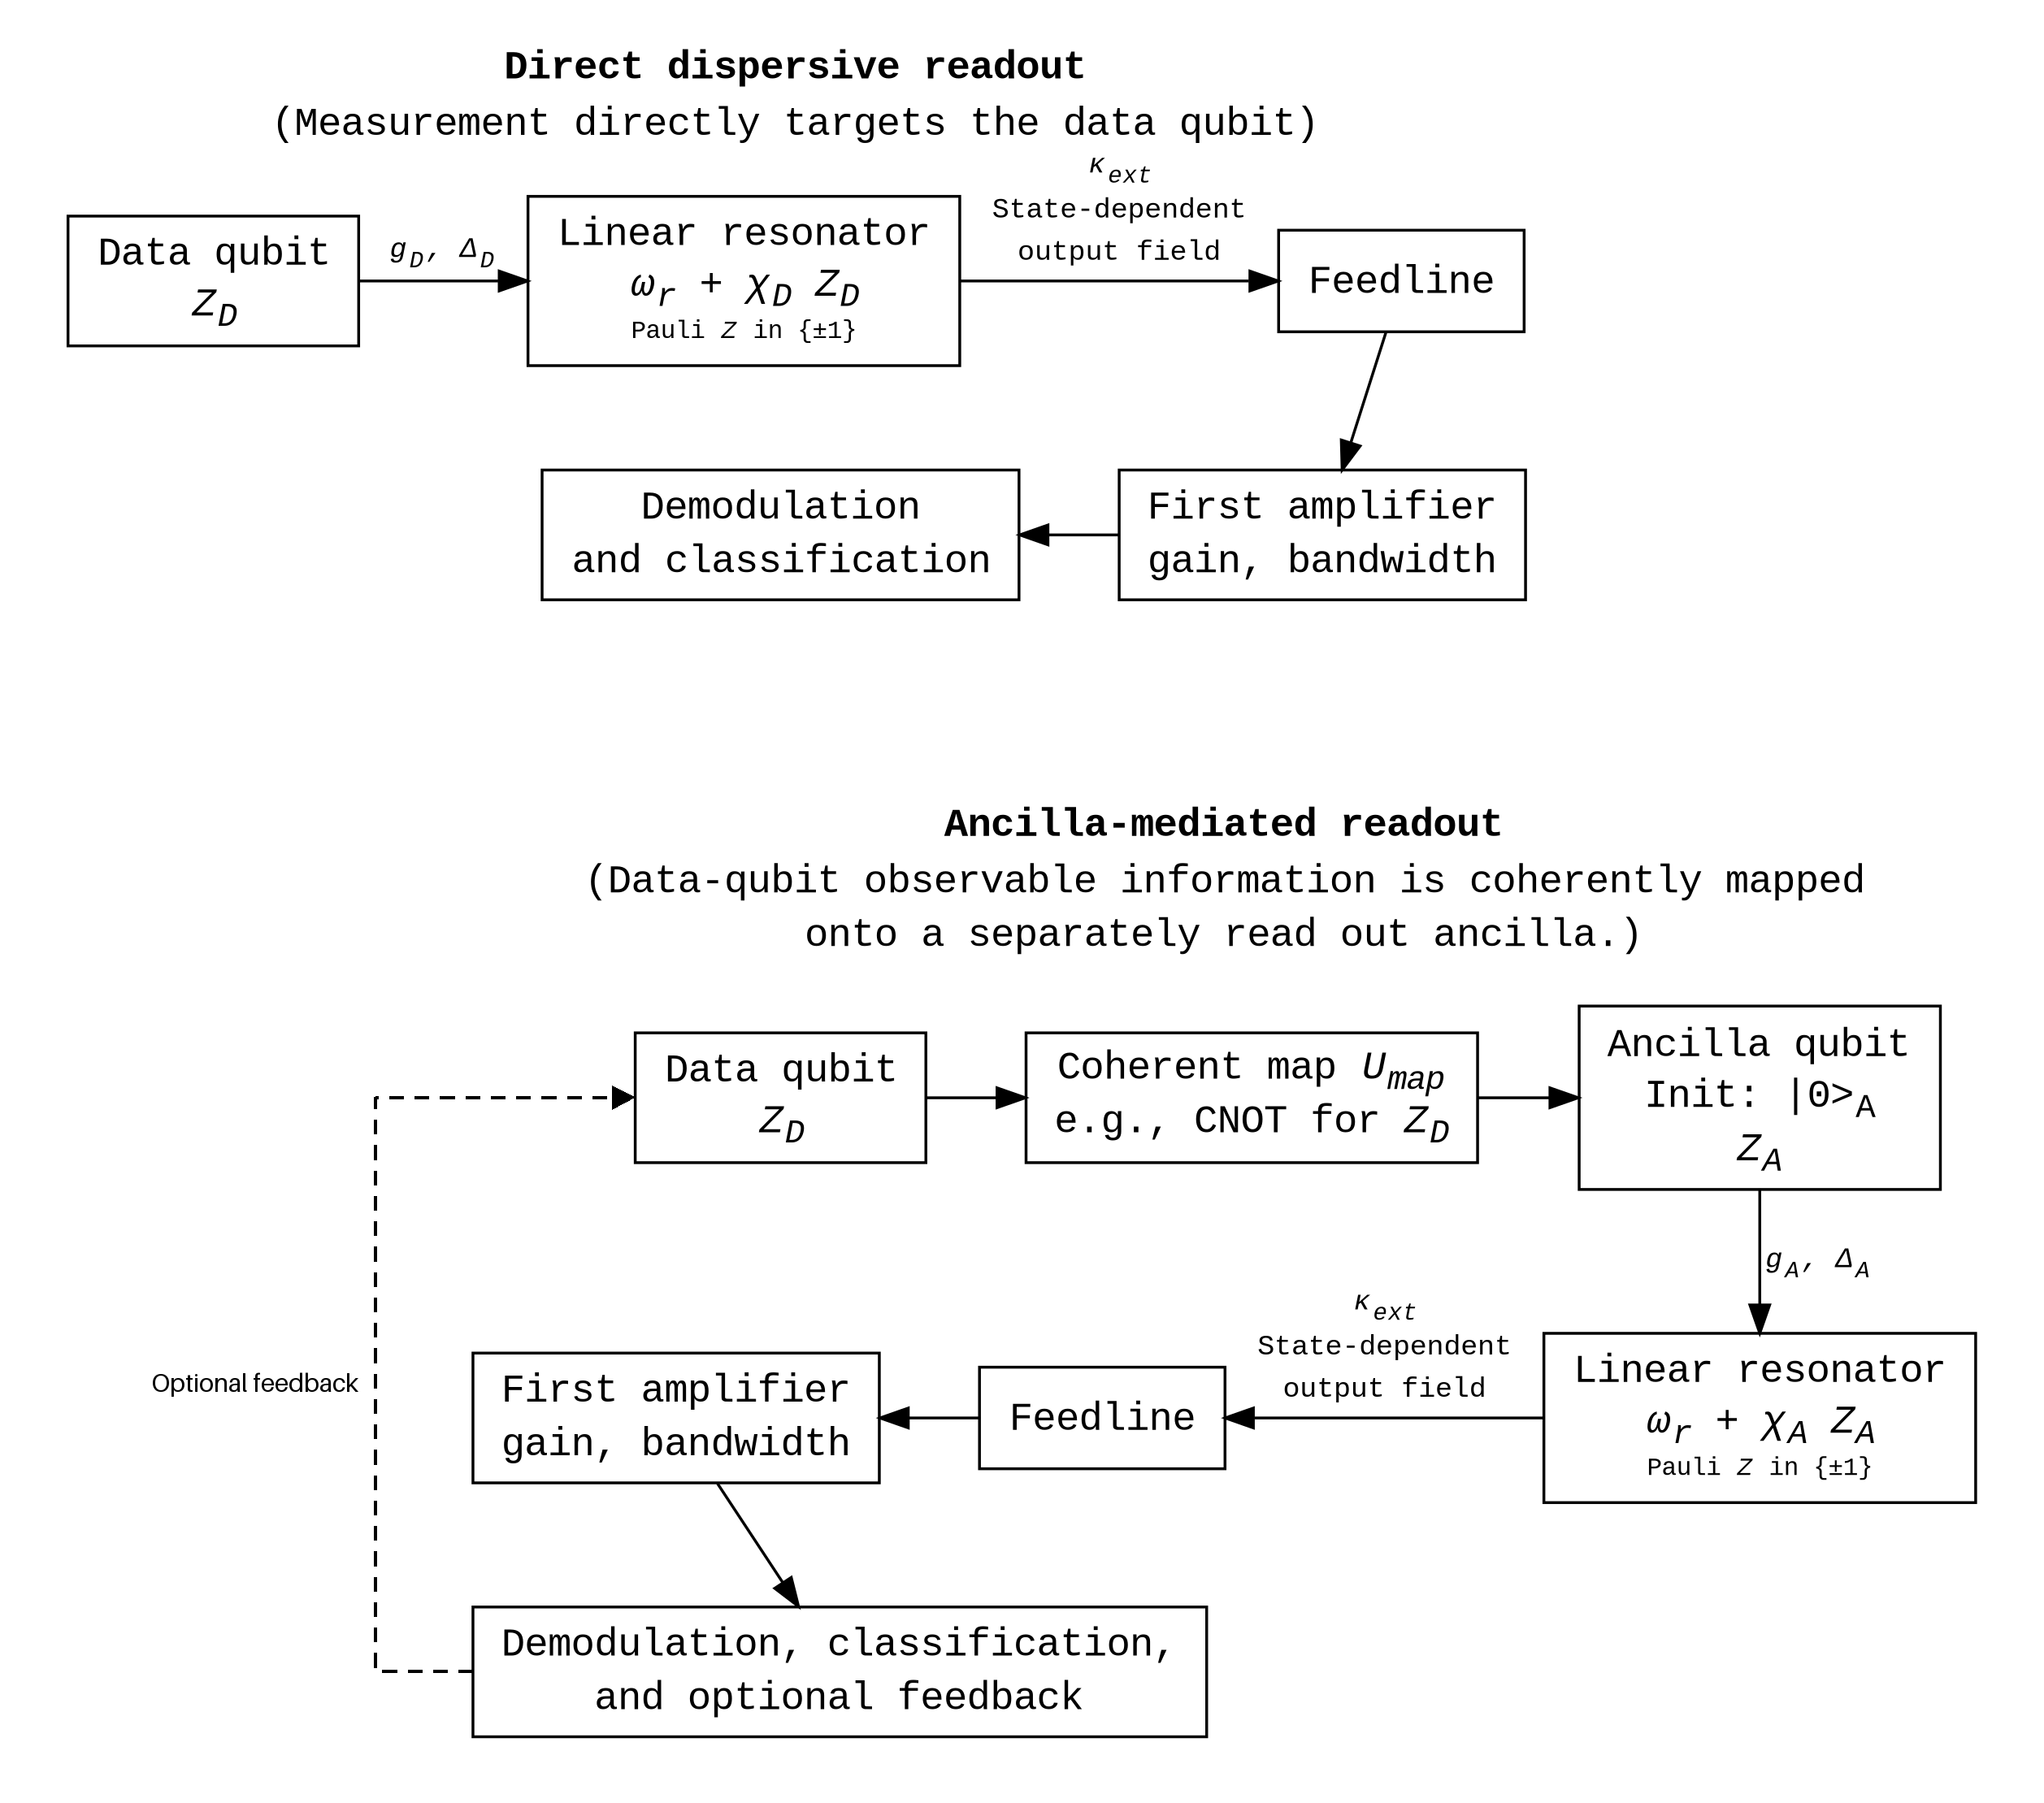

In [34]:
!uv pip install graphviz ipython pillow

"""Render direct and ancilla-mediated quantum readout pathways.

Graphviz arranges the measurement pathways in meandering rows. A dashed
feedback loop returns from ancilla-readout classification to the data qubit.
The 250-DPI PNG is rendered in memory and displayed with a download link.
"""

import base64
import io
import math
import textwrap

import graphviz
from IPython.display import HTML, Image, display
from PIL import Image as PILImage
from PIL import ImageDraw, ImageFont


# --- Control Knobs ---

GRAPH_DPI = 250
NODE_FONT = "DejaVu Sans"
NODE_SHAPE = "box"
EDGE_ROUTING = "spline"

BACKGROUND_COLOR = "white"
FOREGROUND_COLOR = "black"

MAX_CHARACTERS_PER_LINE = 27
DESCRIPTION_CHARACTERS_PER_LINE = 56
MAX_HORIZONTAL_NODES = 3
TITLE_TO_GRAPH_MARGIN = "12.0"
INTER_GRAPH_MINLEN = "2"
GRAPH_PADDING_IN = 0.05

SHOW_FEEDBACK = True
FEEDBACK_LEFT_CLEARANCE_IN = 0.48
FEEDBACK_OUTER_PADDING_IN = 0.20
FEEDBACK_START_VERTICAL_FRACTION = 0.50
FEEDBACK_END_VERTICAL_FRACTION = 0.50

FEEDBACK_LINE_WIDTH_PT = 1.1
FEEDBACK_DASH_PT = 5.0
FEEDBACK_GAP_PT = 4.0
FEEDBACK_ARROW_LENGTH_PT = 8.0
FEEDBACK_ARROW_HALF_WIDTH_PT = 4.2

FEEDBACK_LABEL = "Optional feedback"
FEEDBACK_LABEL_FONT_PT = 9.0
FEEDBACK_LABEL_OFFSET_IN = 0.08

DOWNLOAD_FILENAME = "quantum_measurement_readout.png"


# --- Label Formatting ---

def wrap_text(
    text: str,
    max_width: int = MAX_CHARACTERS_PER_LINE,
) -> str:
    """Wrap plain text while preserving Graphviz HTML labels."""
    text = text.strip()

    if not text:
        return ""

    if text.startswith("<") and text.endswith(">"):
        return text

    return "\n".join(
        textwrap.fill(
            line,
            width=max_width,
            break_long_words=False,
            break_on_hyphens=False,
        )
        for line in text.splitlines()
    )


def html_label(*rows: str) -> str:
    """Build a Graphviz HTML table from formatted rows."""
    contents = "".join(
        f'<TR><TD ALIGN="CENTER">{row}</TD></TR>'
        for row in rows
    )
    return (
        '<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0">'
        f"{contents}</TABLE>>"
    )


def math_label(expression: str) -> str:
    """Format an expression inside a Graphviz HTML label."""
    return f'<FONT FACE="Times New Roman"><I>{expression}</I></FONT>'


# --- Graph Construction ---

def add_meandering_chain(
    tree: graphviz.Digraph,
    path_id: str,
    path_title: str,
    path_desc: str,
    nodes: list,
    max_width: int,
) -> str:
    """Arrange a directed sequence in alternating horizontal rows."""
    if max_width < 1:
        raise ValueError("MAX_HORIZONTAL_NODES must be at least 1.")

    with tree.subgraph(name=f"cluster_{path_id}") as cluster:
        cluster.attr(
            label=html_label(
                f"<B>{path_title}</B>",
                *wrap_text(
                    f"({path_desc})",
                    DESCRIPTION_CHARACTERS_PER_LINE,
                ).splitlines(),
            ),
            fontname=NODE_FONT,
            labelloc="t",
            labeljust="c",
            margin=TITLE_TO_GRAPH_MARGIN,
            color="none",
        )

        chunks = [
            nodes[index:index + max_width]
            for index in range(0, len(nodes), max_width)
        ]

        for row_index, chunk in enumerate(chunks):
            with cluster.subgraph() as rank:
                rank.attr(rank="same")

                for node_id, label, _ in chunk:
                    rank.node(node_id, wrap_text(label))

                if row_index % 2 == 0:
                    for current, following in zip(chunk, chunk[1:]):
                        rank.edge(
                            current[0],
                            following[0],
                            label=wrap_text(current[2], 15),
                        )
                else:
                    for index in range(len(chunk) - 1, 0, -1):
                        current = chunk[index]
                        previous = chunk[index - 1]
                        rank.edge(
                            current[0],
                            previous[0],
                            label=wrap_text(previous[2], 15),
                            dir="back",
                        )

            if row_index + 1 < len(chunks):
                cluster.edge(
                    chunk[-1][0],
                    chunks[row_index + 1][0][0],
                    label=wrap_text(chunk[-1][2], 15),
                )

    return nodes[-1][0]


def build_measurement_pathway_tree() -> graphviz.Digraph:
    """Construct direct and ancilla-mediated readout pathways."""
    tree = graphviz.Digraph(format="png")
    tree.attr(
        dpi=str(GRAPH_DPI),
        splines=EDGE_ROUTING,
        bgcolor=BACKGROUND_COLOR,
        rankdir="TB",
        pad=str(GRAPH_PADDING_IN),
    )
    tree.attr(
        "node",
        shape=NODE_SHAPE,
        style="solid",
        color=FOREGROUND_COLOR,
        fontcolor=FOREGROUND_COLOR,
        fontname=NODE_FONT,
    )
    tree.attr(
        "edge",
        color=FOREGROUND_COLOR,
        fontcolor=FOREGROUND_COLOR,
        arrowhead="normal",
        fontname=NODE_FONT,
        fontsize="10",
    )

    output_field = html_label(
        math_label("κ<SUB>ext</SUB>"),
        "State-dependent",
        "output field",
    )
    pauli_values = '<FONT POINT-SIZE="9">Pauli <I>Z</I> in {±1}</FONT>'

    direct_nodes = [
        (
            "D1",
            html_label("Data qubit", math_label("Z<SUB>D</SUB>")),
            html_label(math_label("g<SUB>D</SUB>, Δ<SUB>D</SUB>")),
        ),
        (
            "D2",
            html_label(
                "Linear resonator",
                math_label("ω<SUB>r</SUB> + χ<SUB>D</SUB> Z<SUB>D</SUB>"),
                pauli_values,
            ),
            output_field,
        ),
        ("D3", html_label("Feedline"), ""),
        ("D4", html_label("First amplifier", "gain, bandwidth"), ""),
        ("D5", html_label("Demodulation", "and classification"), ""),
    ]

    mediated_nodes = [
        (
            "M1",
            html_label("Data qubit", math_label("Z<SUB>D</SUB>")),
            "",
        ),
        (
            "M2",
            html_label(
                "Coherent map " + math_label("U<SUB>map</SUB>"),
                "e.g., CNOT for " + math_label("Z<SUB>D</SUB>"),
            ),
            "",
        ),
        (
            "M3",
            html_label(
                "Ancilla qubit",
                "Init: |0&gt;<SUB>A</SUB>",
                math_label("Z<SUB>A</SUB>"),
            ),
            html_label(math_label("g<SUB>A</SUB>, Δ<SUB>A</SUB>")),
        ),
        (
            "M4",
            html_label(
                "Linear resonator",
                math_label("ω<SUB>r</SUB> + χ<SUB>A</SUB> Z<SUB>A</SUB>"),
                pauli_values,
            ),
            output_field,
        ),
        ("M5", html_label("Feedline"), ""),
        ("M6", html_label("First amplifier", "gain, bandwidth"), ""),
        (
            "M7",
            html_label(
                "Demodulation, classification,",
                "and optional feedback",
            ),
            "",
        ),
    ]

    last_direct = add_meandering_chain(
        tree,
        "Direct",
        "Direct dispersive readout",
        "Measurement directly targets the data qubit",
        direct_nodes,
        MAX_HORIZONTAL_NODES,
    )
    tree.edge(
        last_direct,
        "M1",
        style="invis",
        minlen=INTER_GRAPH_MINLEN,
    )
    add_meandering_chain(
        tree,
        "Mediated",
        "Ancilla-mediated readout",
        "Data-qubit observable information is coherently mapped "
        "onto a separately read out ancilla.",
        mediated_nodes,
        MAX_HORIZONTAL_NODES,
    )
    return tree


# --- Feedback Rendering ---

def load_feedback_font(pixel_size: int) -> ImageFont.ImageFont:
    """Load a sans-serif font for the feedback label."""
    for candidate in (
        "DejaVuSans.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    ):
        try:
            return ImageFont.truetype(candidate, pixel_size)
        except OSError:
            continue

    return ImageFont.load_default(size=pixel_size)


def draw_dashed_polyline(
    draw: ImageDraw.ImageDraw,
    points: list,
    width: int,
    dash_length: float,
    gap_length: float,
) -> None:
    """Draw connected segments with continuous dash spacing."""
    if dash_length <= 0 or gap_length <= 0:
        raise ValueError("Feedback dash and gap lengths must be positive.")

    drawing_dash = True
    remaining = dash_length

    for start, end in zip(points, points[1:]):
        dx = end[0] - start[0]
        dy = end[1] - start[1]
        distance = math.hypot(dx, dy)

        if distance == 0:
            continue

        traversed = 0.0

        while traversed < distance:
            step = min(remaining, distance - traversed)
            first = (
                start[0] + dx * traversed / distance,
                start[1] + dy * traversed / distance,
            )
            traversed += step
            last = (
                start[0] + dx * traversed / distance,
                start[1] + dy * traversed / distance,
            )

            if drawing_dash:
                draw.line([first, last], fill=FOREGROUND_COLOR, width=width)

            remaining -= step

            if remaining <= 1e-9:
                drawing_dash = not drawing_dash
                remaining = dash_length if drawing_dash else gap_length


def render_with_left_feedback(tree: graphviz.Digraph) -> bytes:
    """Render a PNG and add a dashed feedback return along the left side."""
    base_image = PILImage.open(
        io.BytesIO(tree.pipe(format="png"))
    ).convert("RGB")

    if SHOW_FEEDBACK:
        geometry = {}
        graph_width = 0.0
        graph_height = 0.0

        for line in tree.pipe(format="plain").decode("utf-8").splitlines():
            fields = line.split()

            if not fields:
                continue

            if fields[0] == "graph":
                graph_width, graph_height = map(float, fields[2:4])
            elif fields[0] == "node":
                geometry[fields[1]] = tuple(map(float, fields[2:6]))

        if graph_width <= 0 or graph_height <= 0:
            raise RuntimeError("Graphviz returned invalid graph dimensions.")

        # Graphviz plain coordinates exclude the raster's outer padding.
        scale_x = base_image.width / (
            graph_width + 2 * GRAPH_PADDING_IN
        )
        scale_y = base_image.height / (
            graph_height + 2 * GRAPH_PADDING_IN
        )
        pixels_per_inch = (scale_x + scale_y) / 2
        pixels_per_point = pixels_per_inch / 72

        boxes = {}
        for node_id, (x, y, width, height) in geometry.items():
            if node_id.startswith("M"):
                boxes[node_id] = {
                    "left": (x - width / 2 + GRAPH_PADDING_IN) * scale_x,
                    "top": (
                        graph_height - y - height / 2 + GRAPH_PADDING_IN
                    ) * scale_y,
                    "height": height * scale_y,
                }

        data_qubit = boxes["M1"]
        feedback_block = boxes["M7"]

        start = (
            feedback_block["left"],
            feedback_block["top"]
            + feedback_block["height"] * FEEDBACK_START_VERTICAL_FRACTION,
        )
        end = (
            data_qubit["left"],
            data_qubit["top"]
            + data_qubit["height"] * FEEDBACK_END_VERTICAL_FRACTION,
        )

        rail_x = (
            min(box["left"] for box in boxes.values())
            - FEEDBACK_LEFT_CLEARANCE_IN * pixels_per_inch
        )
        font = load_feedback_font(
            max(1, round(FEEDBACK_LABEL_FONT_PT * pixels_per_point))
        )
        label_bounds = font.getbbox(FEEDBACK_LABEL)
        label_width = label_bounds[2] - label_bounds[0]
        label_height = label_bounds[3] - label_bounds[1]
        label_offset = FEEDBACK_LABEL_OFFSET_IN * pixels_per_inch
        outer_padding = FEEDBACK_OUTER_PADDING_IN * pixels_per_inch

        extra_left = max(
            0,
            math.ceil(
                outer_padding + label_width + label_offset - rail_x
            ),
        )
        canvas = PILImage.new(
            "RGB",
            (base_image.width + extra_left, base_image.height),
            BACKGROUND_COLOR,
        )
        canvas.paste(base_image, (extra_left, 0))
        base_image = canvas

        start = (start[0] + extra_left, start[1])
        end = (end[0] + extra_left, end[1])
        rail_x += extra_left

        # Horizontal entry and exit segments join a dedicated vertical rail.
        points = [
            start,
            (rail_x, start[1]),
            (rail_x, end[1]),
            end,
        ]
        draw = ImageDraw.Draw(base_image)
        draw_dashed_polyline(
            draw,
            points,
            max(1, round(FEEDBACK_LINE_WIDTH_PT * pixels_per_point)),
            FEEDBACK_DASH_PT * pixels_per_point,
            FEEDBACK_GAP_PT * pixels_per_point,
        )

        arrow_length = FEEDBACK_ARROW_LENGTH_PT * pixels_per_point
        arrow_half_width = FEEDBACK_ARROW_HALF_WIDTH_PT * pixels_per_point
        draw.polygon(
            [
                end,
                (end[0] - arrow_length, end[1] - arrow_half_width),
                (end[0] - arrow_length, end[1] + arrow_half_width),
            ],
            fill=FOREGROUND_COLOR,
        )

        label_x = rail_x - label_offset - label_width
        label_y = (start[1] + end[1] - label_height) / 2
        draw.text(
            (
                label_x - label_bounds[0],
                label_y - label_bounds[1],
            ),
            FEEDBACK_LABEL,
            font=font,
            fill=FOREGROUND_COLOR,
        )

    output = io.BytesIO()
    base_image.save(
        output,
        format="PNG",
        dpi=(GRAPH_DPI, GRAPH_DPI),
    )
    return output.getvalue()


# --- Display and Download ---

def display_and_generate_download(tree: graphviz.Digraph) -> None:
    """Display the diagram and provide an in-memory PNG download link."""
    png_data = render_with_left_feedback(tree)
    display(Image(data=png_data))

    encoded = base64.b64encode(png_data).decode("ascii")

pathway_tree = build_measurement_pathway_tree()
display_and_generate_download(pathway_tree)